# V-Magnet IPM Rotor — Concepts and Variations

This notebook visualises the V-shaped interior PM rotor topology and how its
key design parameters shape the geometry.  All plots are produced analytically
from `MotorParams` — no FEM solve is needed.

**Sections**
1. Flat vs V topology — side-by-side comparison  
2. V-magnet anatomy — single sector with every parameter labelled  
3. `alpha_v` sweep — half V-angle effect  
4. `w_mag_v` sweep — magnet width effect  
5. Bridge thickness variations — `t_bridge_outer` and `t_bridge_inner`  
6. Actual meshed geometry — three representative designs  
7. Quantitative parameter table

In [1]:
import math, sys, tempfile
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import Arc, FancyArrowPatch
import gmsh

sys.path.insert(0, str(Path('.').resolve()))
from motor_params import MotorParams
from gen_rotor import build_rotor

π = math.pi

matplotlib.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 10,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'font.family': 'sans-serif',
})

# ── Colour palette ────────────────────────────────────────────────────────────
C_IRON   = '#4A6FAA'   # rotor iron (blue)
C_MAG_R  = '#CC44CC'   # right V-magnet (magenta)
C_MAG_L  = '#882288'   # left  V-magnet (dark magenta)
C_MAG_F  = '#CC44CC'   # flat magnet
C_BAR    = '#7799DD'   # flux barrier (light blue)
C_PKT    = '#99AACC'   # flat air pocket
C_SHAFT  = '#888888'   # shaft
C_GAP    = '#D8EEFA'   # airgap
C_DAXIS  = '#FF8800'   # d-axis annotation

print('Imports OK')

Imports OK


In [2]:
# ── Analytical drawing helpers ────────────────────────────────────────────────

def rot_pts(pts, angle):
    """Rotate a list of (x, y) tuples CCW by angle [rad]."""
    c, s = np.cos(angle), np.sin(angle)
    return [(x * c - y * s, x * s + y * c) for x, y in pts]


def _rot2d(x, y, angle):
    """Rotate point (x, y) CCW by angle [rad]."""
    c, s = np.cos(angle), np.sin(angle)
    return x * c - y * s, x * s + y * c


def rect_local(x0, dx, y0, dy):
    """Four corners of a rectangle [CCW] in local coordinates."""
    return [(x0, y0), (x0 + dx, y0), (x0 + dx, y0 + dy), (x0, y0 + dy)]


def _rotor_clip(ax, p):
    """Return a sector polygon (0..θs, 0..R_ro) added to ax, usable as clip path."""
    θ_arc = np.linspace(0, p.θs, 100)
    pts = [(0, 0)] + [(p.R_ro * np.cos(t), p.R_ro * np.sin(t)) for t in θ_arc]
    clip = mpatches.Polygon(pts, closed=True)
    ax.add_patch(clip)
    clip.set_visible(False)
    return clip


def draw_base(ax, p, gap=True):
    """Airgap strip, rotor iron wedge, shaft wedge."""
    θd = np.degrees(p.θs)
    if gap:
        ax.add_patch(mpatches.Wedge((0, 0), p.R_sb, 0, θd,
                                    width=p.R_sb - p.R_ro,
                                    color=C_GAP, lw=0, zorder=1))
    ax.add_patch(mpatches.Wedge((0, 0), p.R_ro, 0, θd,
                                width=p.R_ro - p.R_ri,
                                color=C_IRON, lw=0, zorder=2))
    ax.add_patch(mpatches.Wedge((0, 0), p.R_ri, 0, θd,
                                width=p.R_ri, color=C_SHAFT, lw=0, zorder=3))
    # Sector boundary lines
    for θ in (0, p.θs):
        ax.plot([0, p.R_sb * np.cos(θ)], [0, p.R_sb * np.sin(θ)],
                'k-', lw=0.7, zorder=20)
    # OD arc
    θa = np.linspace(0, p.θs, 300)
    ax.plot(p.R_ro * np.cos(θa), p.R_ro * np.sin(θa), 'k-', lw=0.7, zorder=20)


def draw_flat_magnet(ax, p):
    """Draw the flat inset magnet and air pockets."""
    θ_c = p.θs / 2
    clip = _rotor_clip(ax, p)
    # Magnet
    corners = rot_pts(rect_local(p.R_mi, p.h_m, -p.w_mag / 2, p.w_mag), θ_c)
    m = mpatches.Polygon(corners, color=C_MAG_F, zorder=5, lw=0)
    ax.add_patch(m)
    m.set_clip_path(clip)
    # Air pockets
    if p.w_air > 0:
        for y0 in (-p.w_mag / 2 - p.w_air, p.w_mag / 2):
            c = rot_pts(rect_local(p.R_mi, p.h_m, y0, p.w_air), θ_c)
            pk = mpatches.Polygon(c, color=C_PKT, zorder=5, lw=0)
            ax.add_patch(pk)
            pk.set_clip_path(clip)


def draw_V_magnets(ax, p):
    """Draw V-magnet pair and inner d-axis barriers.

    Asymmetric placement: the d-axis end of each magnet is at local y=0
    (radius = R_mi — the apex of the V), and extends toward the sector
    boundary (larger radius).  Parts outside the sector are clipped.

    Inner barriers fill from the magnet d-axis tip (θ_m) to the iron
    bridge edge (θ_c ± θ_bh).
    """
    θ_c   = p.θs / 2
    alpha = np.radians(p.alpha_v)
    θ_bh  = np.arctan2(p.t_bridge_inner / 2, p.R_mi)
    clip  = _rotor_clip(ax, p)
    colors = (C_MAG_R, C_MAG_L)

    for i, sign in enumerate((-1, +1)):
        θ_m = θ_c + sign * alpha

        # ── Magnet: d-axis end at local y=0 (r=R_mi), extends toward sector edge ──
        # right (sign=-1): y ∈ [−w_mag_v, 0];  left (sign=+1): y ∈ [0, +w_mag_v]
        y0_rect = -p.w_mag_v if sign == -1 else 0.0
        corners = rot_pts(rect_local(p.R_mi, p.h_m, y0_rect, p.w_mag_v), θ_m)
        mp = mpatches.Polygon(corners, color=colors[i], zorder=5, lw=0)
        ax.add_patch(mp)
        mp.set_clip_path(clip)

        # ── Inner d-axis barrier ──────────────────────────────────────────────
        # Fills the region from the magnet d-axis tip (at θ_m) to the iron
        # bridge edge (at θ_c ± θ_bh).
        θ_be  = θ_c + sign * θ_bh
        P_di  = _rot2d(p.R_mi, 0.0, θ_m)   # magnet inner face, d-axis end
        P_do  = _rot2d(p.R_mo, 0.0, θ_m)   # magnet outer face, d-axis end
        P_bi  = (p.R_mi * np.cos(θ_be), p.R_mi * np.sin(θ_be))
        P_bo  = (p.R_mo * np.cos(θ_be), p.R_mo * np.sin(θ_be))

        if sign == -1:
            inner_pts = [P_di, P_do, P_bo, P_bi]   # CCW
        else:
            inner_pts = [P_di, P_bi, P_bo, P_do]   # CCW

        ip = mpatches.Polygon(inner_pts, color=C_BAR, zorder=4, lw=0)
        ax.add_patch(ip)
        ip.set_clip_path(clip)


def draw_mag_arrows(ax, p):
    """White arrows showing magnetisation direction on each V-magnet."""
    θ_c = p.θs / 2
    alpha_rad = np.radians(p.alpha_v)
    # Arrow at the centre of each magnet (shifted toward sector edge)
    for sign in (-1, +1):
        rot = θ_c + sign * alpha_rad
        # Centre of the asymmetric magnet: local (r_ctr, -sign*w_mag_v/2)
        r_ctr = (p.R_mi + p.R_mo) / 2
        cx, cy = _rot2d(r_ctr, -sign * p.w_mag_v / 2, rot)
        length = p.h_m * 0.7
        ax.annotate('', xy=(cx + length * np.cos(rot), cy + length * np.sin(rot)),
                    xytext=(cx - length * np.cos(rot), cy - length * np.sin(rot)),
                    arrowprops=dict(arrowstyle='->', color='white', lw=1.6),
                    zorder=15)


def draw_daxis(ax, p, r=None, label=True):
    """Draw the d-axis as a dashed orange line."""
    θ_c = p.θs / 2
    r = r or p.R_sb
    ax.plot([0, r * np.cos(θ_c)], [0, r * np.sin(θ_c)],
            '--', color=C_DAXIS, lw=1.0, zorder=18)
    if label:
        ax.text(r * 1.02 * np.cos(θ_c), r * 1.02 * np.sin(θ_c),
                'd', color=C_DAXIS, fontsize=8, ha='center', va='bottom',
                fontweight='bold')


def finish_ax(ax, p, margin=3.0):
    """Set equal aspect + tight limits + no spine."""
    ax.set_aspect('equal')
    ax.set_xlim(-margin, p.R_sb + margin)
    ax.set_ylim(-margin, p.R_sb * np.sin(p.θs) + margin)
    ax.axis('off')


# Reference design (flat baseline)
p_flat = MotorParams()
# Default V design
p_v = MotorParams(magnet_layout='V', alpha_v=10.0, w_mag_v=20.0,
                  t_bridge_outer=1.0, t_bridge_inner=2.0)
print(f'Flat:  R_ro={p_flat.R_ro:.2f} mm, R_mi={p_flat.R_mi:.2f} mm')
print(f'V:     R_ro={p_v.R_ro:.2f} mm,   R_mi={p_v.R_mi:.2f} mm')
print(f'V:     theta_c={np.degrees(p_v.θs/2):.1f}°,  alpha_v={p_v.alpha_v}°')
print(f'       right magnet at rot={np.degrees(p_v.θs/2 - np.radians(p_v.alpha_v)):.1f}°')
print(f'       left  magnet at rot={np.degrees(p_v.θs/2 + np.radians(p_v.alpha_v)):.1f}°')

Flat:  R_ro=73.25 mm, R_mi=65.25 mm
V:     R_ro=73.25 mm,   R_mi=65.25 mm
V:     theta_c=22.5°,  alpha_v=10.0°
       right magnet at rot=12.5°
       left  magnet at rot=32.5°


## 1. Flat vs V Topology — Side-by-Side

| Feature | Flat inset-PM | Single-layer V-IPM |
|---|---|---|
| Magnets per pole | 1 tangential | 2 tilted (V-pair) |
| Flux focusing | None | Moderate |
| Saliency L_q/L_d | 1.5–2.5 | 2.5–4.0 |
| Reluctance torque share | ~10–20 % | ~25–45 % |

The key difference: in the V topology each magnet's **magnetisation direction
is tilted ±α from the d-axis**.  Orthogonality to the long face is preserved
(user requirement) — the rotation angle of the rectangle equals the
magnetisation angle.

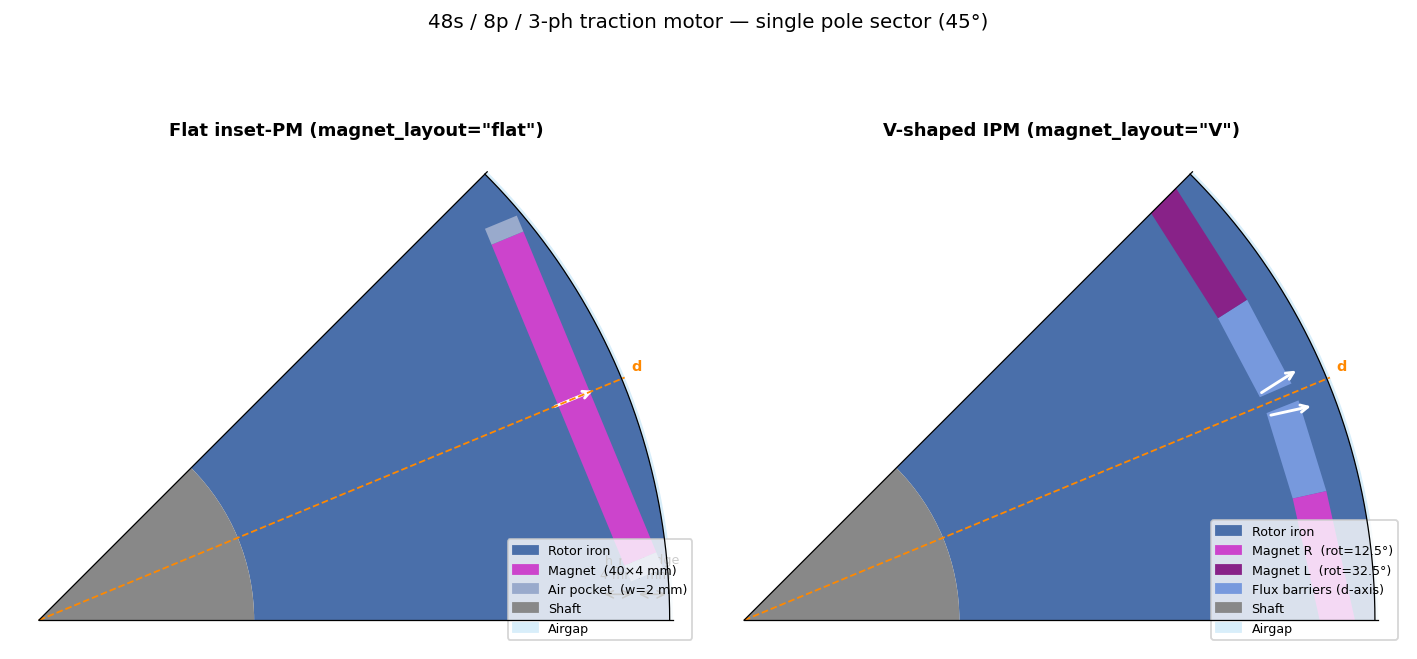

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

# ── Left: flat inset-PM ───────────────────────────────────────────────────────
ax = axes[0]
draw_base(ax, p_flat)
draw_flat_magnet(ax, p_flat)
draw_daxis(ax, p_flat)

# Magnetisation arrow on flat magnet
θ_c = p_flat.θs / 2
r_ctr = (p_flat.R_mi + p_flat.R_mo) / 2
L = p_flat.h_m * 0.7
ax.annotate('', xy=(r_ctr * np.cos(θ_c) + L * np.cos(θ_c),
                    r_ctr * np.sin(θ_c) + L * np.sin(θ_c)),
            xytext=(r_ctr * np.cos(θ_c) - L * np.cos(θ_c),
                    r_ctr * np.sin(θ_c) - L * np.sin(θ_c)),
            arrowprops=dict(arrowstyle='->', color='white', lw=1.6), zorder=15)

# Dimension callouts
ax.annotate('', xy=(p_flat.R_ro, 3), xytext=(p_flat.R_mo, 3),
            arrowprops=dict(arrowstyle='<->', color='k', lw=0.9))
ax.text((p_flat.R_ro + p_flat.R_mo) / 2, 4.5,
        f'h_bridge\n{p_flat.h_bridge:.0f} mm',
        ha='center', va='bottom', fontsize=7)
ax.annotate('', xy=(p_flat.R_mo, 3), xytext=(p_flat.R_mi, 3),
            arrowprops=dict(arrowstyle='<->', color='k', lw=0.9))
ax.text((p_flat.R_mo + p_flat.R_mi) / 2, 4.5,
        f'h_m\n{p_flat.h_m:.0f} mm',
        ha='center', va='bottom', fontsize=7)

finish_ax(ax, p_flat)
ax.set_title('Flat inset-PM (magnet_layout="flat")', fontweight='bold')
axes[0].legend(handles=[
    mpatches.Patch(color=C_IRON,  label='Rotor iron'),
    mpatches.Patch(color=C_MAG_F, label=f'Magnet  ({p_flat.w_mag:.0f}×{p_flat.h_m:.0f} mm)'),
    mpatches.Patch(color=C_PKT,   label=f'Air pocket  (w={p_flat.w_air:.0f} mm)'),
    mpatches.Patch(color=C_SHAFT, label='Shaft'),
    mpatches.Patch(color=C_GAP,   label='Airgap'),
], fontsize=7, loc='lower right')

# ── Right: V-IPM ─────────────────────────────────────────────────────────────
ax = axes[1]
draw_base(ax, p_v)
draw_V_magnets(ax, p_v)
draw_mag_arrows(ax, p_v)
draw_daxis(ax, p_v)

finish_ax(ax, p_v)
ax.set_title('V-shaped IPM (magnet_layout="V")', fontweight='bold')
axes[1].legend(handles=[
    mpatches.Patch(color=C_IRON,  label='Rotor iron'),
    mpatches.Patch(color=C_MAG_R, label=f'Magnet R  (rot={p_v.θs/2*180/π - p_v.alpha_v:.1f}°)'),
    mpatches.Patch(color=C_MAG_L, label=f'Magnet L  (rot={p_v.θs/2*180/π + p_v.alpha_v:.1f}°)'),
    mpatches.Patch(color=C_BAR,   label='Flux barriers (d-axis)'),
    mpatches.Patch(color=C_SHAFT, label='Shaft'),
    mpatches.Patch(color=C_GAP,   label='Airgap'),
], fontsize=7, loc='lower right')

plt.suptitle('48s / 8p / 3-ph traction motor — single pole sector (45°)',
             fontsize=11, y=1.01)
plt.tight_layout()
Path('results/png').mkdir(parents=True, exist_ok=True)
plt.savefig('results/png/v_flat_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. V-Magnet Anatomy — Annotated Parameter Diagram

Every free parameter of the V rotor is labelled on a single sector.  
The magnetisation direction (white arrow) is **orthogonal to the longest face**
(w_mag_v dimension): it is the local x-axis direction after rotating by
`θ_c ± alpha_v_rad`, which equals the rotation angle of the rectangle.

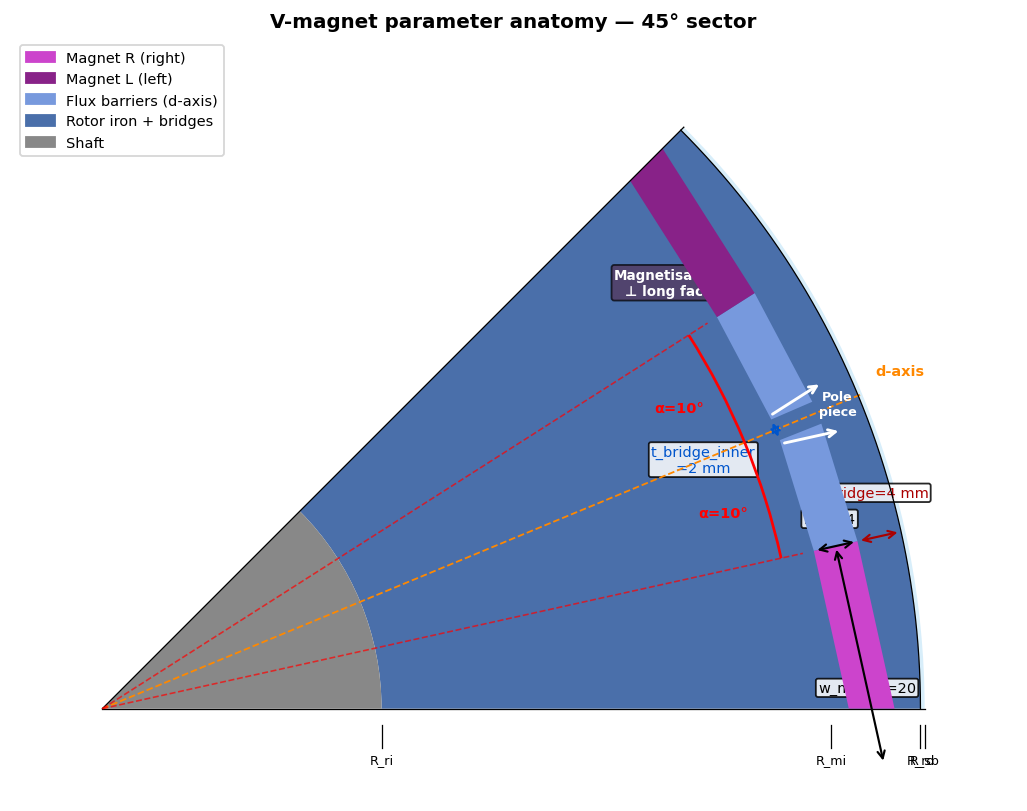

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))

p = p_v
draw_base(ax, p)
draw_V_magnets(ax, p)
draw_mag_arrows(ax, p)
draw_daxis(ax, p, label=False)

θ_c = p.θs / 2
alpha_rad = np.radians(p.alpha_v)
θ_bh = np.arctan2(p.t_bridge_inner / 2, p.R_mi)

# ── d-axis label ──────────────────────────────────────────────────────────────
ax.text(p.R_sb * 1.05 * np.cos(θ_c), p.R_sb * 1.05 * np.sin(θ_c),
        'd-axis', color=C_DAXIS, fontsize=8, ha='center', va='bottom',
        fontweight='bold')

# ── alpha_v arc annotation ────────────────────────────────────────────────────
r_arc = p.R_mi - 3
arc_right = Arc((0, 0), 2 * r_arc, 2 * r_arc,
                theta1=np.degrees(θ_c - alpha_rad),
                theta2=np.degrees(θ_c),
                color='red', lw=1.5, zorder=25)
ax.add_patch(arc_right)
arc_left = Arc((0, 0), 2 * r_arc, 2 * r_arc,
               theta1=np.degrees(θ_c),
               theta2=np.degrees(θ_c + alpha_rad),
               color='red', lw=1.5, zorder=25)
ax.add_patch(arc_left)
for θ_lbl, label in [(θ_c - alpha_rad / 2, f'α={p.alpha_v:.0f}°'),
                      (θ_c + alpha_rad / 2, f'α={p.alpha_v:.0f}°')]:
    ax.text((r_arc - 4) * np.cos(θ_lbl), (r_arc - 4) * np.sin(θ_lbl),
            label, color='red', fontsize=8, ha='center', va='center',
            fontweight='bold')

# Draw the two rotation direction lines
for sign in (-1, +1):
    rot = θ_c + sign * alpha_rad
    ax.plot([0, (p.R_mi - 1) * np.cos(rot)], [0, (p.R_mi - 1) * np.sin(rot)],
            'r--', lw=0.9, zorder=22, alpha=0.7)

# ── h_m (right magnet, along its magnetisation direction) ─────────────────────
rot_r = θ_c - alpha_rad
x_hm_inner = p.R_mi * np.cos(rot_r)
y_hm_inner = p.R_mi * np.sin(rot_r)
x_hm_outer = p.R_mo * np.cos(rot_r)
y_hm_outer = p.R_mo * np.sin(rot_r)
ax.annotate('', xy=(x_hm_outer, y_hm_outer), xytext=(x_hm_inner, y_hm_inner),
            arrowprops=dict(arrowstyle='<->', color='k', lw=1.2), zorder=30)
mid = ((x_hm_inner + x_hm_outer) / 2, (y_hm_inner + y_hm_outer) / 2)
perp = (-np.sin(rot_r), np.cos(rot_r))
ax.text(mid[0] + 2.5 * perp[0], mid[1] + 2.5 * perp[1],
        f'h_m={p.h_m:.0f}', fontsize=8, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.85))

# ── w_mag_v (right magnet, along the long axis, d-axis end → sector-edge end) ─
# Right magnet: local y ∈ [−w_mag_v, 0] → d-axis end at y=0, sector end at y=−w_mag_v
long_dir = (np.cos(rot_r + π / 2), np.sin(rot_r + π / 2))
r_ctr_r = (p.R_mi + p.R_mo) / 2
P_wm_daxis  = _rot2d(r_ctr_r,         0.0, rot_r)   # d-axis end (local y=0)
P_wm_sector = _rot2d(r_ctr_r, -p.w_mag_v, rot_r)   # sector-edge end (local y=−w_mag_v)
ax.annotate('', xy=P_wm_sector, xytext=P_wm_daxis,
            arrowprops=dict(arrowstyle='<->', color='k', lw=1.2), zorder=30)
mid_wm = ((P_wm_daxis[0] + P_wm_sector[0]) / 2,
          (P_wm_daxis[1] + P_wm_sector[1]) / 2)
ax.text(mid_wm[0] - 3.0 * long_dir[0], mid_wm[1] - 3.0 * long_dir[1],
        f'w_mag_v={p.w_mag_v:.0f}',
        fontsize=8, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.85))

# ── h_bridge (OD iron bridge: R_mo → R_ro along rot_r radial line) ─────────────
ax.annotate('', xy=(p.R_ro * np.cos(rot_r), p.R_ro * np.sin(rot_r)),
            xytext=(p.R_mo * np.cos(rot_r), p.R_mo * np.sin(rot_r)),
            arrowprops=dict(arrowstyle='<->', color='#AA0000', lw=1.2), zorder=30)
mid_br = ((p.R_mo + p.R_ro) / 2 * np.cos(rot_r),
          (p.R_mo + p.R_ro) / 2 * np.sin(rot_r))
ax.text(mid_br[0] + 4 * (-np.sin(rot_r)), mid_br[1] + 4 * np.cos(rot_r),
        f'h_bridge={p.h_bridge:.0f} mm', fontsize=8, color='#AA0000',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.85))

# ── t_bridge_inner (d-axis iron bridge width at R_mi) ─────────────────────────
# Bridge spans from θ_c-θ_bh to θ_c+θ_bh at R_mi
P_be_R = (p.R_mi * np.cos(θ_c - θ_bh), p.R_mi * np.sin(θ_c - θ_bh))
P_be_L = (p.R_mi * np.cos(θ_c + θ_bh), p.R_mi * np.sin(θ_c + θ_bh))
ax.annotate('', xy=P_be_L, xytext=P_be_R,
            arrowprops=dict(arrowstyle='<->', color='#0055CC', lw=1.2), zorder=30)
mid_ib = ((P_be_R[0] + P_be_L[0]) / 2, (P_be_R[1] + P_be_L[1]) / 2)
# Offset label inward (toward origin)
r_mid = np.sqrt(mid_ib[0]**2 + mid_ib[1]**2)
ax.text(mid_ib[0] * (r_mid - 7) / r_mid, mid_ib[1] * (r_mid - 7) / r_mid,
        f't_bridge_inner\n={p.t_bridge_inner:.0f} mm', fontsize=8, color='#0055CC',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.85))

# ── Radial dimension bars at θ=0 ─────────────────────────────────────────────
for r, label in [(p.R_ri, 'R_ri'), (p.R_mi, 'R_mi'),
                 (p.R_ro, 'R_ro'), (p.R_sb, 'R_sb')]:
    ax.plot([r, r], [-1.5, -3.5], 'k-', lw=0.7, zorder=30)
    ax.text(r, -4, label, ha='center', va='top', fontsize=7)

# ── Magnetisation label ───────────────────────────────────────────────────────
r_ctr_l = (p.R_mi + p.R_mo) / 2
rot_l = θ_c + alpha_rad
ax.text(r_ctr_l * np.cos(rot_l) - 6,
        r_ctr_l * np.sin(rot_l) + 2,
        'Magnetisation\n⊥ long face', fontsize=7.5, color='white',
        ha='center', va='center', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', fc='#553355', alpha=0.7))

# ── Pole-piece label ──────────────────────────────────────────────────────────
r_pp = p.R_mo + (p.R_ro - p.R_mo) * 0.5
ax.text(r_pp * np.cos(θ_c), r_pp * np.sin(θ_c),
        'Pole\npiece', fontsize=7, color='white',
        ha='center', va='center', fontweight='bold', zorder=30)

finish_ax(ax, p, margin=8)
ax.set_title('V-magnet parameter anatomy — 45° sector', fontweight='bold', fontsize=11)
ax.legend(handles=[
    mpatches.Patch(color=C_MAG_R,  label='Magnet R (right)'),
    mpatches.Patch(color=C_MAG_L,  label='Magnet L (left)'),
    mpatches.Patch(color=C_BAR,    label='Flux barriers (d-axis)'),
    mpatches.Patch(color=C_IRON,   label='Rotor iron + bridges'),
    mpatches.Patch(color=C_SHAFT,  label='Shaft'),
], fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('results/png/v_anatomy.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Half V-Angle (`alpha_v`) Sweep

`alpha_v` is the **mechanical** angular offset of each magnet centre from the
d-axis.  For 48s/8p (sector = 45°) it must be < 20.25° to keep both magnets
inside the sector.

- Small `alpha_v` → nearly flat, magnets close to d-axis → low saliency  
- Large `alpha_v` → wide V, magnets near sector boundaries → high L_q/L_d  
- Rotation angle of each magnet = θ_c ± alpha_v [rad] = magnetisation direction

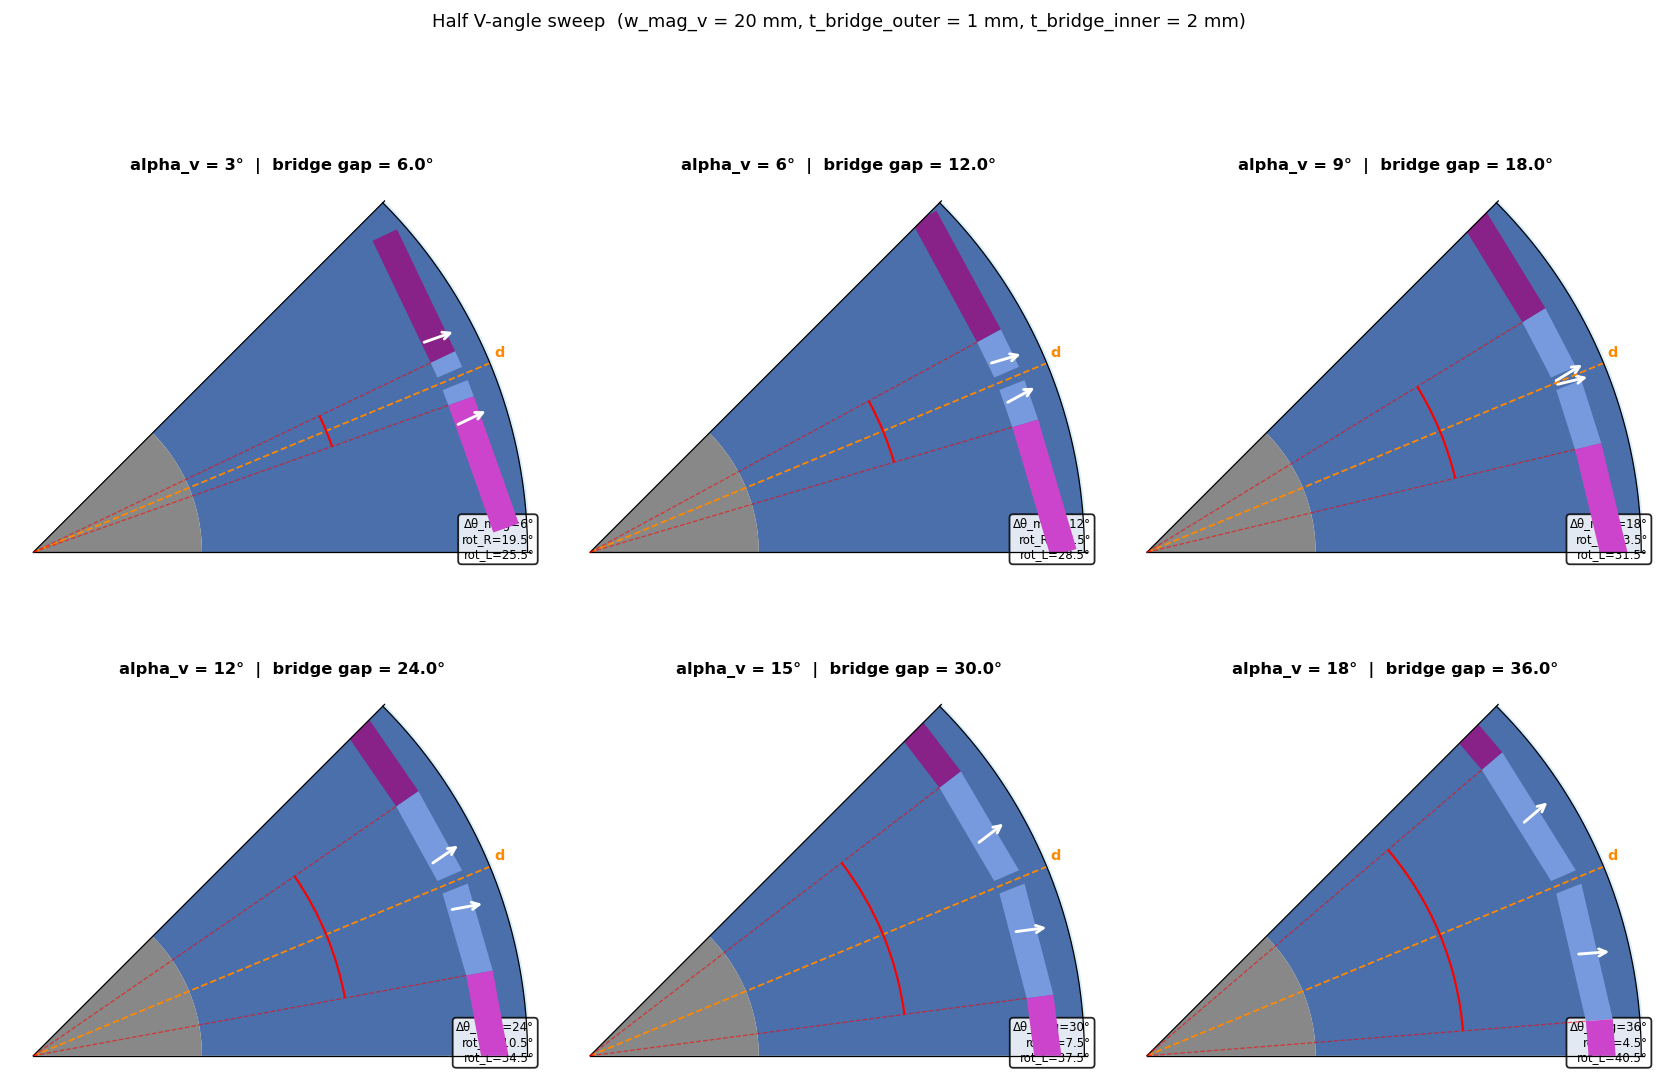

In [5]:
alpha_vals = [3.0, 6.0, 9.0, 12.0, 15.0, 18.0]

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
axes = axes.flatten()

for ax, alpha in zip(axes, alpha_vals):
    p = MotorParams(magnet_layout='V', alpha_v=alpha,
                    w_mag_v=20.0, t_bridge_outer=1.0, t_bridge_inner=2.0)

    draw_base(ax, p)
    draw_V_magnets(ax, p)
    draw_mag_arrows(ax, p)
    draw_daxis(ax, p, r=p.R_ro)

    # Show rotation directions with thin lines from origin
    θ_c = p.θs / 2
    alpha_rad = np.radians(alpha)
    rot_r = θ_c - alpha_rad
    rot_l = θ_c + alpha_rad
    for rot in (rot_r, rot_l):
        ax.plot([0, p.R_mi * np.cos(rot)], [0, p.R_mi * np.sin(rot)],
                'r--', lw=0.7, alpha=0.6, zorder=20)

    # Arc showing alpha_v
    r_arc = p.R_mi * 0.72
    ax.add_patch(Arc((0, 0), 2 * r_arc, 2 * r_arc,
                     theta1=np.degrees(θ_c - alpha_rad),
                     theta2=np.degrees(θ_c + alpha_rad),
                     color='red', lw=1.2, zorder=22))

    # D-axis iron bridge angular span (angle between the two magnet rotation axes)
    gap_deg = 2 * alpha

    finish_ax(ax, p)
    ax.set_title(f'alpha_v = {alpha:.0f}°  |  bridge gap = {gap_deg:.1f}°',
                 fontsize=9, fontweight='bold')

    # Concise info box
    ax.text(0.97, 0.03,
            f'Δθ_mag={2*alpha:.0f}°\nrot_R={np.degrees(rot_r):.1f}°\nrot_L={np.degrees(rot_l):.1f}°',
            transform=ax.transAxes, fontsize=6.5,
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

fig.suptitle('Half V-angle sweep  (w_mag_v = 20 mm, t_bridge_outer = 1 mm, t_bridge_inner = 2 mm)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('results/png/v_alpha_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Magnet Width (`w_mag_v`) Sweep

Wider magnets:  
- More magnet material → stronger magnet torque component  
- Outer tips get closer to sector boundaries → eventually need smaller alpha_v  
- Pole piece iron (between outer faces and OD) gets narrower tangentially

The outer tip angle from d-axis depends on both `w_mag_v` and `alpha_v`.

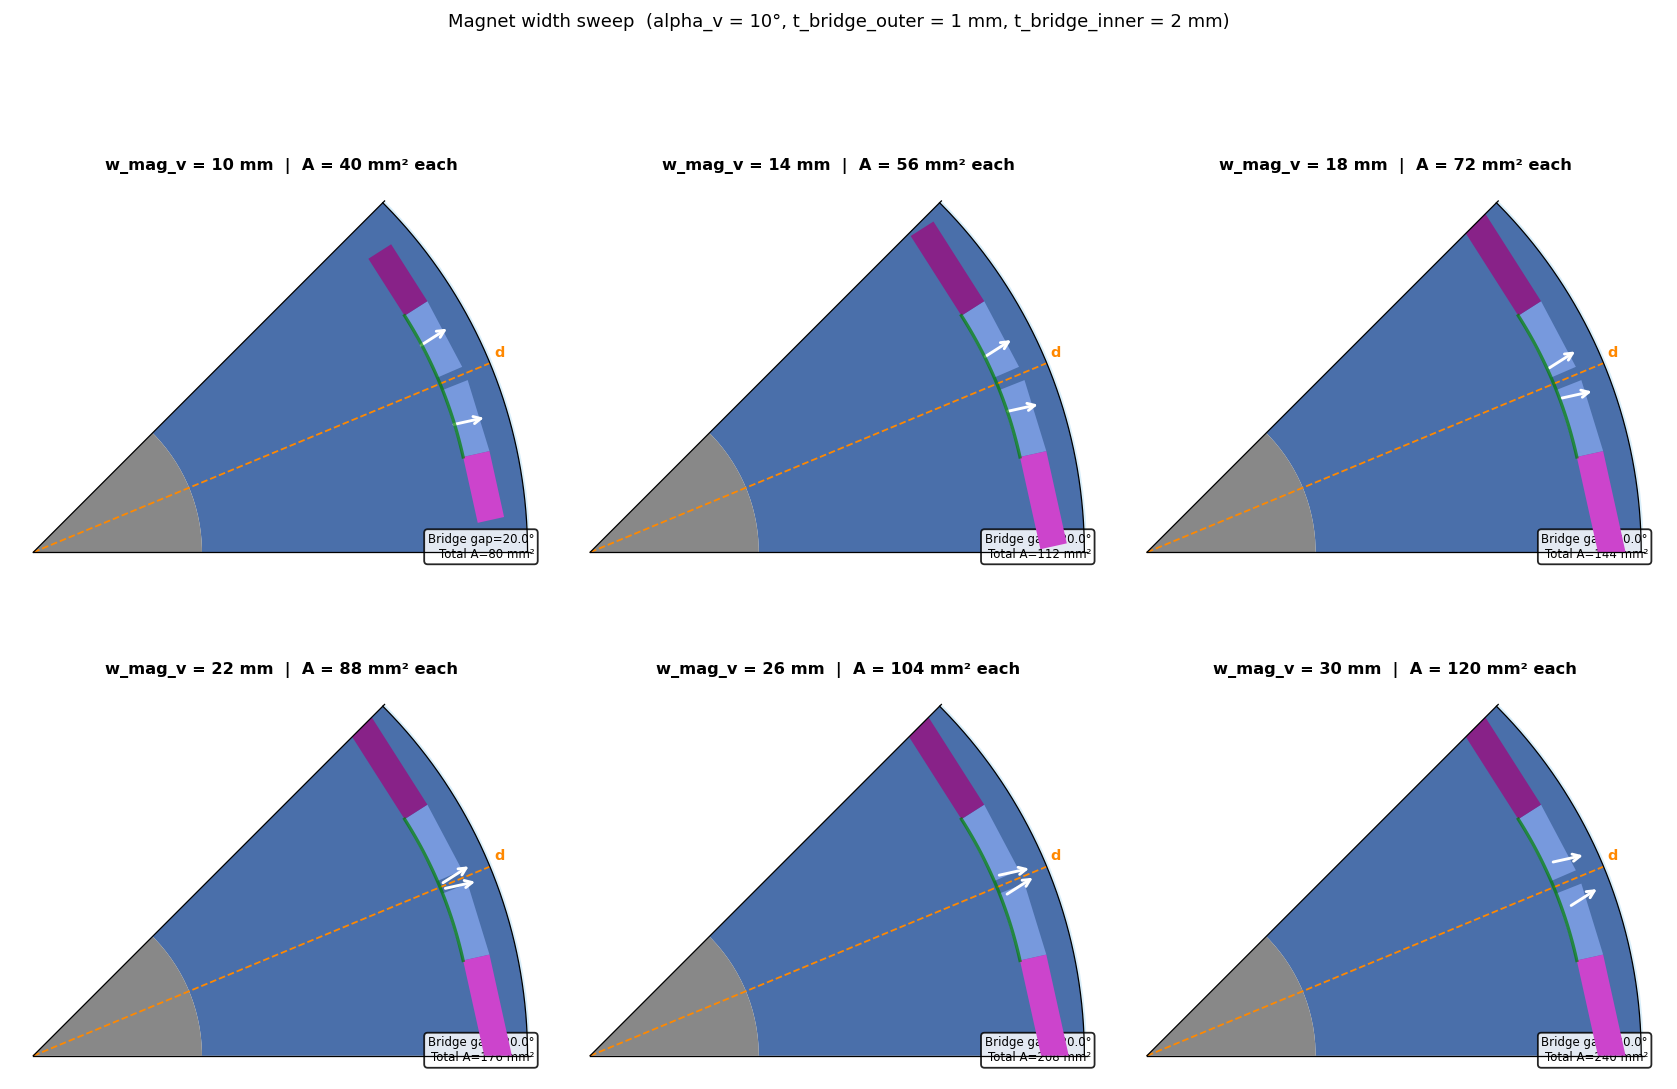

In [6]:
wmag_vals = [10.0, 14.0, 18.0, 22.0, 26.0, 30.0]

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
axes = axes.flatten()

for ax, wm in zip(axes, wmag_vals):
    try:
        p = MotorParams(magnet_layout='V', alpha_v=10.0, w_mag_v=wm,
                        t_bridge_outer=1.0, t_bridge_inner=2.0)
    except ValueError as e:
        ax.text(0.5, 0.5, f'w_mag_v={wm:.0f} mm\nINVALID\n{str(e)[:60]}',
                transform=ax.transAxes, ha='center', va='center', fontsize=7,
                color='red', wrap=True)
        ax.axis('off')
        ax.set_title(f'w_mag_v = {wm:.0f} mm  [invalid]', fontsize=9)
        continue

    draw_base(ax, p)
    draw_V_magnets(ax, p)
    draw_mag_arrows(ax, p)
    draw_daxis(ax, p, r=p.R_ro)

    # D-axis iron bridge arc at R_mi (spans between the two magnet rotation angles)
    θ_c = p.θs / 2
    alpha_rad = np.radians(p.alpha_v)
    rot_r = θ_c - alpha_rad
    rot_l = θ_c + alpha_rad
    θ_bridge = np.linspace(rot_r, rot_l, 60)
    ax.plot(p.R_mi * np.cos(θ_bridge), p.R_mi * np.sin(θ_bridge),
            'g-', lw=1.8, zorder=25, alpha=0.7)

    gap_deg = 2 * np.degrees(alpha_rad)
    A_one = p.h_m * wm

    finish_ax(ax, p)
    ax.set_title(f'w_mag_v = {wm:.0f} mm  |  A = {A_one:.0f} mm² each',
                 fontsize=9, fontweight='bold')
    ax.text(0.97, 0.03,
            f'Bridge gap={gap_deg:.1f}°\nTotal A={2*A_one:.0f} mm²',
            transform=ax.transAxes, fontsize=6.5,
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

fig.suptitle('Magnet width sweep  (alpha_v = 10°, t_bridge_outer = 1 mm, t_bridge_inner = 2 mm)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('results/png/v_wmag_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Bridge Thickness Variations

Two sub-sweeps showing the two iron bridge parameters:

**Left column**: `t_bridge_outer` — thin iron bridge at the rotor OD between
the arc-sector barrier tip and the rotor surface.  
- Thinner → less flux leakage, better saliency  
- Practical floor: 0.5–1.0 mm (manufacturing, centrifugal stress)

**Right column**: `t_bridge_inner` — iron bridge width along the d-axis between
the two inner quadrilateral barriers.  
- Thinner → more effective flux decoupling between magnet halves  
- Practical floor: 0.5–1.0 mm  
- Sets the half-angle `θ_bh = atan2(t_bridge_inner/2, R_mi)` of each inner barrier

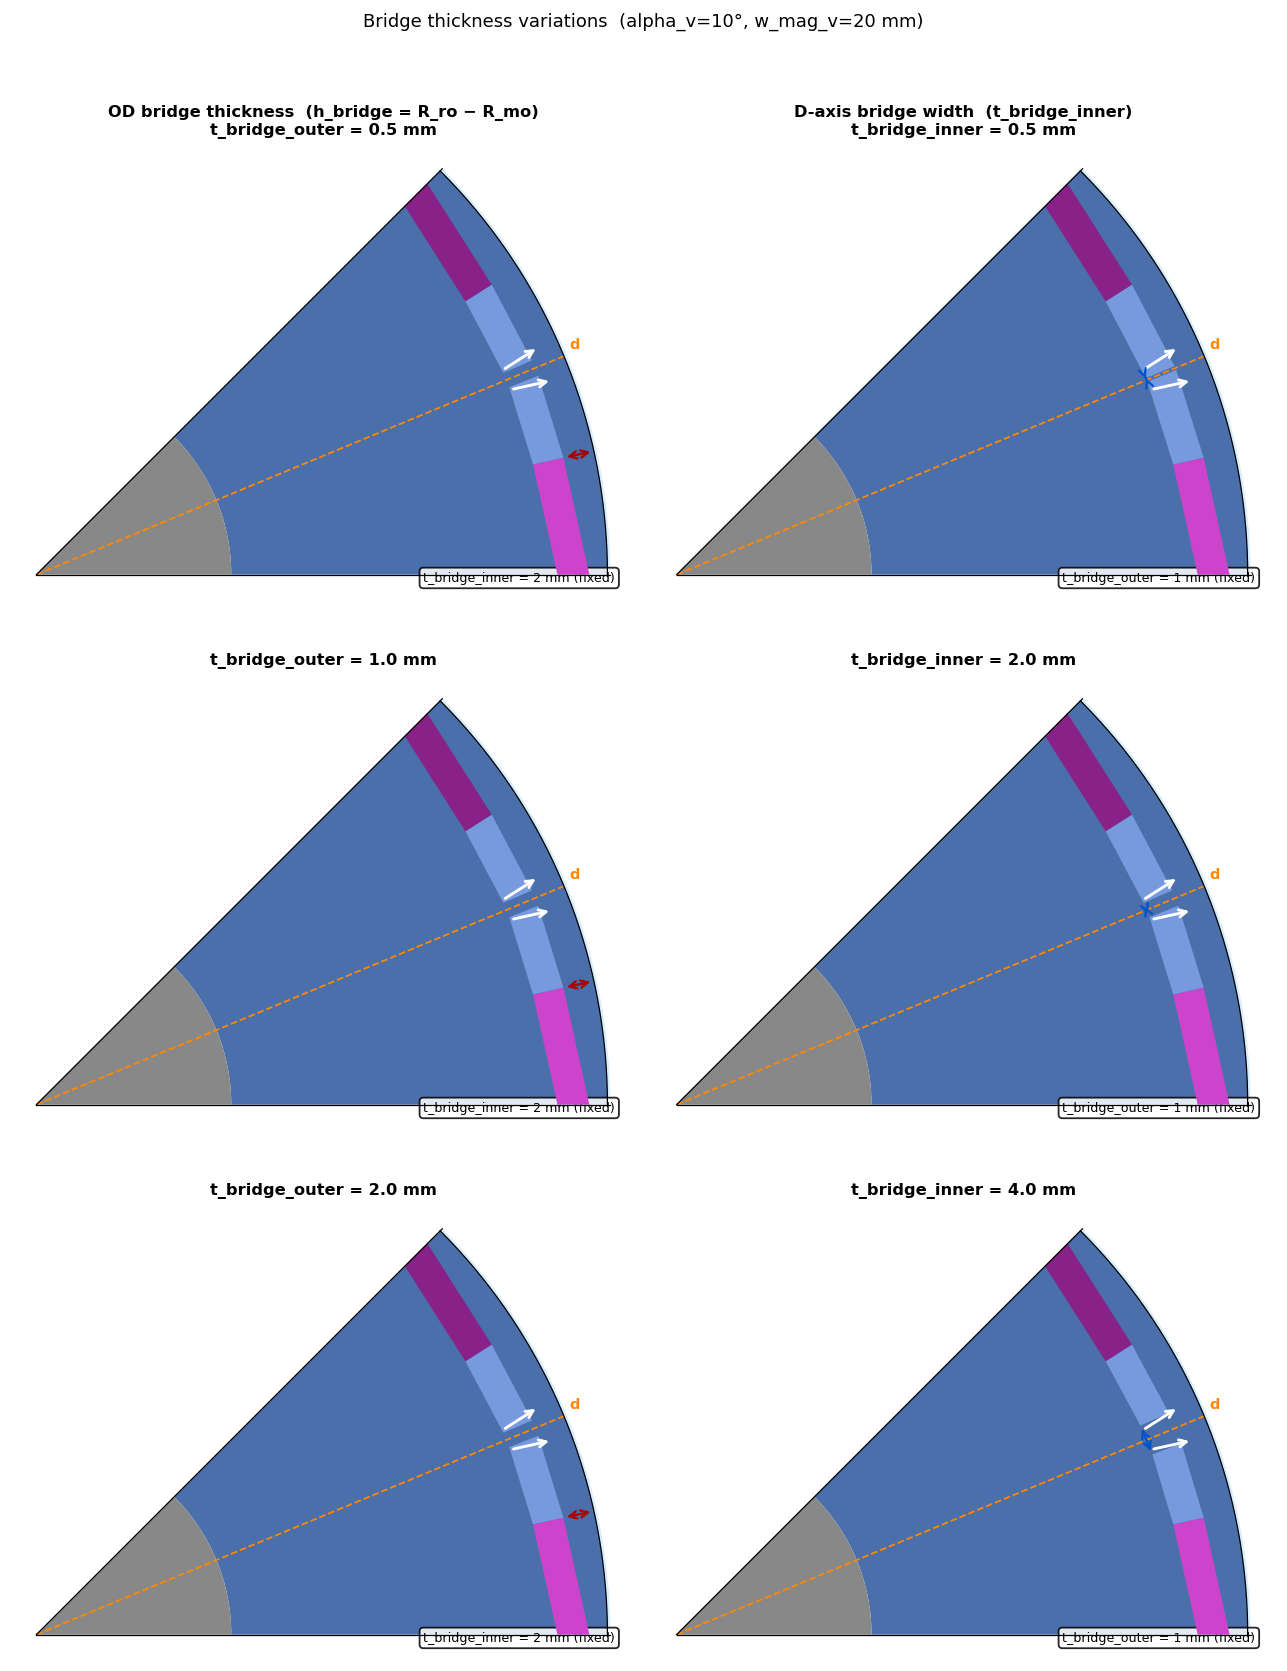

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(10, 13))

bridge_outer_vals = [0.5, 1.0, 2.0]
bridge_inner_vals = [0.5, 2.0, 4.0]

for row, (t_outer, t_inner) in enumerate(zip(bridge_outer_vals, bridge_inner_vals)):

    # ── Left: vary t_bridge_outer ─────────────────────────────────────────────
    ax = axes[row, 0]
    p = MotorParams(magnet_layout='V', alpha_v=10.0, w_mag_v=20.0,
                    t_bridge_outer=t_outer, t_bridge_inner=2.0)
    draw_base(ax, p)
    draw_V_magnets(ax, p)
    draw_mag_arrows(ax, p)
    draw_daxis(ax, p, r=p.R_ro)

    # Mark the OD bridge: R_mo → R_ro along the right magnet radial direction
    rot_r = p.θs / 2 - np.radians(p.alpha_v)
    ax.annotate('', xy=(p.R_ro * np.cos(rot_r), p.R_ro * np.sin(rot_r)),
                xytext=(p.R_mo * np.cos(rot_r), p.R_mo * np.sin(rot_r)),
                arrowprops=dict(arrowstyle='<->', color='#AA0000', lw=1.3),
                zorder=30)

    finish_ax(ax, p)
    ax.set_title(f't_bridge_outer = {t_outer:.1f} mm', fontsize=9, fontweight='bold')
    ax.text(0.97, 0.03, 't_bridge_inner = 2 mm (fixed)',
            transform=ax.transAxes, fontsize=7,
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

    # ── Right: vary t_bridge_inner ────────────────────────────────────────────
    ax = axes[row, 1]
    p = MotorParams(magnet_layout='V', alpha_v=10.0, w_mag_v=20.0,
                    t_bridge_outer=1.0, t_bridge_inner=t_inner)
    draw_base(ax, p)
    draw_V_magnets(ax, p)
    draw_mag_arrows(ax, p)
    draw_daxis(ax, p, r=p.R_ro)

    # Mark the d-axis bridge with a blue arc
    θ_c = p.θs / 2
    θ_bh = np.arctan2(t_inner / 2, p.R_mi)
    P_be_R = (p.R_mi * np.cos(θ_c - θ_bh), p.R_mi * np.sin(θ_c - θ_bh))
    P_be_L = (p.R_mi * np.cos(θ_c + θ_bh), p.R_mi * np.sin(θ_c + θ_bh))
    ax.annotate('', xy=P_be_L, xytext=P_be_R,
                arrowprops=dict(arrowstyle='<->', color='#0055CC', lw=1.3),
                zorder=30)

    finish_ax(ax, p)
    ax.set_title(f't_bridge_inner = {t_inner:.1f} mm', fontsize=9, fontweight='bold')
    ax.text(0.97, 0.03, 't_bridge_outer = 1 mm (fixed)',
            transform=ax.transAxes, fontsize=7,
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

axes[0, 0].set_title('OD bridge thickness  (h_bridge = R_ro − R_mo)\n' +
                     axes[0, 0].get_title(), fontsize=9, fontweight='bold')
axes[0, 1].set_title('D-axis bridge width  (t_bridge_inner)\n' +
                     axes[0, 1].get_title(), fontsize=9, fontweight='bold')

plt.suptitle('Bridge thickness variations  (alpha_v=10°, w_mag_v=20 mm)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('results/png/v_bridge_barrier_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Actual Meshed Geometry (gmsh)

Build and render the actual triangular FEM mesh for three representative designs
using `build_rotor()`.  Colour shows physical group assignment.


Rotor classification [flat] (6 total surfaces):
  Rotor iron   : 1 surface(s)
  Magnet       : 1 surface(s)  (A = 161.3 mm² actual, 161.3 mm² rect)
  Air pockets  : 2 surface(s)  (expected 2)
  Shaft        : 1 surface(s)
  Airgap rotor : 1 surface(s)

Boundaries:
  SB_Rotor     : [14]
  Rotor_Right  : 3 curves
  Rotor_Left   : 3 curves

Generating rotor mesh ...
Mesh: 1602 nodes, 2962 2D elements
Written: /var/folders/66/l7z1xmd57kb2lqj_7cvg3c900000gp/T/tmpmwy4_c2f.msh

Rotor classification [V] (7 total surfaces):
  Rotor iron   : 5 surface(s)
  Magnet (R+L) : 2 surface(s)  (A = 119.3 mm² actual, 80.0 mm² rect each ×2)
  Barriers     : 2 surface(s)  (expected 2)
  Shaft        : 1 surface(s)
  Airgap rotor : 1 surface(s)

Boundaries:
  SB_Rotor     : [18]
  Rotor_Right  : 5 curves
  Rotor_Left   : 5 curves

Generating rotor mesh ...
Mesh: 1673 nodes, 3112 2D elements
Written: /var/folders/66/l7z1xmd57kb2lqj_7cvg3c900000gp/T/tmpfheg95va.msh

Rotor classification [V] (7 total surfaces)

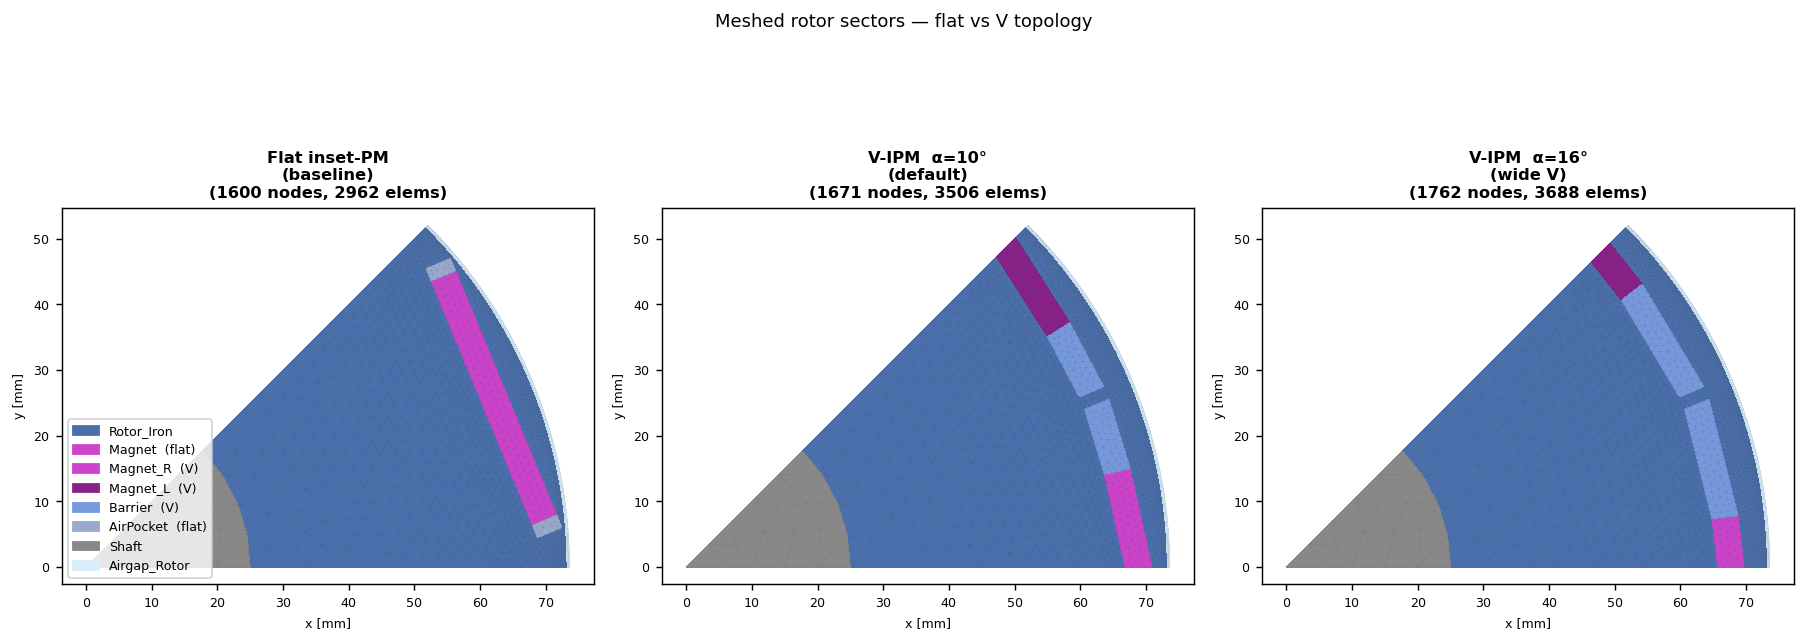

In [8]:
import matplotlib.tri as mtri
import matplotlib.colors as mcolors

def load_rotor_msh(msh_path):
    """Load a rotor .msh4 and return (xy_mm, tris{name: (N,3)})."""
    if gmsh.isInitialized():
        gmsh.finalize()
    gmsh.initialize()
    gmsh.option.setNumber('General.Terminal', 0)
    gmsh.model.add('viz')
    try:
        gmsh.merge(str(msh_path))
        ntags, coords, _ = gmsh.model.mesh.getNodes()
        xy = coords.reshape(-1, 3)[:, :2]
        t2i = {int(t): i for i, t in enumerate(ntags)}
        tris = {}
        for dim, pg in gmsh.model.getPhysicalGroups():
            if dim != 2:
                continue
            nm  = gmsh.model.getPhysicalName(dim, pg)
            ens = gmsh.model.getEntitiesForPhysicalGroup(dim, pg)
            rows = []
            for e in ens:
                etypes, _, ntags_e = gmsh.model.mesh.getElements(2, e)
                for etype, nn in zip(etypes, ntags_e):
                    if int(etype) == 2:
                        rows.append(nn.reshape(-1, 3))
            if rows:
                raw = np.vstack(rows)
                tris[nm] = np.array([[t2i[int(x)] for x in r] for r in raw])
        return xy, tris
    finally:
        gmsh.finalize()


def body_color_rotor(name):
    if 'Rotor_Iron' in name: return C_IRON
    if 'Magnet_R'   in name: return C_MAG_R
    if 'Magnet_L'   in name: return C_MAG_L
    if 'Magnet'     in name: return C_MAG_F   # flat case
    if 'Barrier'    in name: return C_BAR
    if 'AirPocket'  in name: return C_PKT
    if 'Shaft'      in name: return C_SHAFT
    if 'Airgap'     in name: return C_GAP
    return '#DDDDDD'


def render_msh(ax, xy, tris, lw=0.1):
    """Render triangulated mesh with body colours."""
    for name, tri in tris.items():
        if len(tri) == 0:
            continue
        c = body_color_rotor(name)
        triang = mtri.Triangulation(xy[:, 0], xy[:, 1], tri)
        ax.tripcolor(triang, facecolors=np.zeros(len(tri)),
                     cmap=mcolors.ListedColormap([c]))
        ax.triplot(triang, color='#333333', lw=lw, alpha=0.35)


designs = [
    ('Flat inset-PM\n(baseline)',
     MotorParams()),
    ('V-IPM  α=10°\n(default)',
     MotorParams(magnet_layout='V', alpha_v=10.0, w_mag_v=20.0,
                 t_bridge_outer=1.0, t_bridge_inner=2.0)),
    ('V-IPM  α=16°\n(wide V)',
     MotorParams(magnet_layout='V', alpha_v=16.0, w_mag_v=18.0,
                 t_bridge_outer=1.0, t_bridge_inner=2.0)),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5))

for ax, (title, p_des) in zip(axes, designs):
    with tempfile.NamedTemporaryFile(suffix='.msh', delete=False) as f:
        msh_path = Path(f.name)
    build_rotor(p_des, mesh_out=msh_path)
    xy, tris = load_rotor_msh(msh_path)

    n_nodes = len(xy)
    n_elems = sum(len(t) for t in tris.values())
    render_msh(ax, xy, tris)

    ax.set_aspect('equal')
    ax.set_xlabel('x [mm]', fontsize=7)
    ax.set_ylabel('y [mm]', fontsize=7)
    ax.set_title(f'{title}\n({n_nodes} nodes, {n_elems} elems)', fontsize=9,
                 fontweight='bold')
    ax.tick_params(labelsize=7)

# Shared legend
axes[0].legend(handles=[
    mpatches.Patch(color=C_IRON,  label='Rotor_Iron'),
    mpatches.Patch(color=C_MAG_F, label='Magnet  (flat)'),
    mpatches.Patch(color=C_MAG_R, label='Magnet_R  (V)'),
    mpatches.Patch(color=C_MAG_L, label='Magnet_L  (V)'),
    mpatches.Patch(color=C_BAR,   label='Barrier  (V)'),
    mpatches.Patch(color=C_PKT,   label='AirPocket  (flat)'),
    mpatches.Patch(color=C_SHAFT, label='Shaft'),
    mpatches.Patch(color=C_GAP,   label='Airgap_Rotor'),
], fontsize=7, loc='lower left')

plt.suptitle('Meshed rotor sectors — flat vs V topology', fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('results/png/v_mesh_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Quantitative Parameter Table

Summary of geometry quantities across the `alpha_v` sweep, including magnet
area, pole coverage, and magnetisation angles for the SIF.

In [9]:
from IPython.display import display
import importlib
try:
    import pandas as pd
    USE_PANDAS = True
except ImportError:
    USE_PANDAS = False

alpha_range = [3, 6, 9, 12, 15, 18]
rows = []
for alpha in alpha_range:
    p = MotorParams(magnet_layout='V', alpha_v=alpha, w_mag_v=20.0,
                    t_bridge_outer=1.0, t_bridge_inner=2.0)
    θ_c = p.θs / 2
    alpha_rad = np.radians(alpha)

    # Rotation angles of the two magnets
    rot_r = np.degrees(θ_c - alpha_rad)
    rot_l = np.degrees(θ_c + alpha_rad)

    # Outer tip angles (farthest from d-axis for each magnet)
    outer_r = rot_pts([(p.R_mi, -p.w_mag_v / 2)], θ_c - alpha_rad)[0]
    outer_l = rot_pts([(p.R_mi, +p.w_mag_v / 2)], θ_c + alpha_rad)[0]
    θ_outer_r = np.degrees(np.arctan2(outer_r[1], outer_r[0]))
    θ_outer_l = np.degrees(np.arctan2(outer_l[1], outer_l[0]))

    # Inner tip angles (nearest d-axis for each magnet)
    inner_r = rot_pts([(p.R_mi, +p.w_mag_v / 2)], θ_c - alpha_rad)[0]
    inner_l = rot_pts([(p.R_mi, -p.w_mag_v / 2)], θ_c + alpha_rad)[0]
    θ_inner_r = np.degrees(np.arctan2(inner_r[1], inner_r[0]))
    θ_inner_l = np.degrees(np.arctan2(inner_l[1], inner_l[0]))

    apex_gap_deg = θ_inner_l - θ_inner_r  # angular gap at d-axis (pole piece)
    pole_cov_deg = θ_outer_l - θ_outer_r   # total angular span at R_mi
    pole_cov_pct = pole_cov_deg / np.degrees(p.θs) * 100

    A_total = 2 * p.h_m * p.w_mag_v  # total magnet cross-section

    # Magnetisation angles in SIF
    mangle1 = np.degrees(θ_c)
    mangle_R = mangle1 - alpha
    mangle_L = mangle1 + alpha

    # D-axis bridge half-angle
    θ_bh_deg = np.degrees(np.arctan2(p.t_bridge_inner / 2, p.R_mi))

    rows.append({
        'alpha_v [°]':       alpha,
        'rot_R [°]':         round(rot_r, 1),
        'rot_L [°]':         round(rot_l, 1),
        'Mangle_R [°]':      round(mangle_R, 1),
        'Mangle_L [°]':      round(mangle_L, 1),
        'θ_outer span [°]':  round(pole_cov_deg, 1),
        'pole cov [%]':      round(pole_cov_pct, 0),
        'apex gap [°]':      round(apex_gap_deg, 1),
        'θ_bh [°]':          round(θ_bh_deg, 2),
        'A_total [mm²]':     round(A_total, 0),
    })

if USE_PANDAS:
    import pandas as pd
    df = pd.DataFrame(rows)
    display(df.to_string(index=False))
else:
    # Plain text table
    headers = list(rows[0].keys())
    col_w = [max(len(h), max(len(str(r[h])) for r in rows)) + 2 for h in headers]
    header_line = '  '.join(h.ljust(w) for h, w in zip(headers, col_w))
    print(header_line)
    print('-' * len(header_line))
    for row in rows:
        print('  '.join(str(row[h]).ljust(w) for h, w in zip(headers, col_w)))

' alpha_v [°]  rot_R [°]  rot_L [°]  Mangle_R [°]  Mangle_L [°]  θ_outer span [°]  pole cov [%]  apex gap [°]  θ_bh [°]  A_total [mm²]\n           3       19.5       25.5          19.5          25.5              23.4          52.0         -11.4      0.88          160.0\n           6       16.5       28.5          16.5          28.5              29.4          65.0          -5.4      0.88          160.0\n           9       13.5       31.5          13.5          31.5              35.4          79.0           0.6      0.88          160.0\n          12       10.5       34.5          10.5          34.5              41.4          92.0           6.6      0.88          160.0\n          15        7.5       37.5           7.5          37.5              47.4         105.0          12.6      0.88          160.0\n          18        4.5       40.5           4.5          40.5              53.4         119.0          18.6      0.88          160.0'

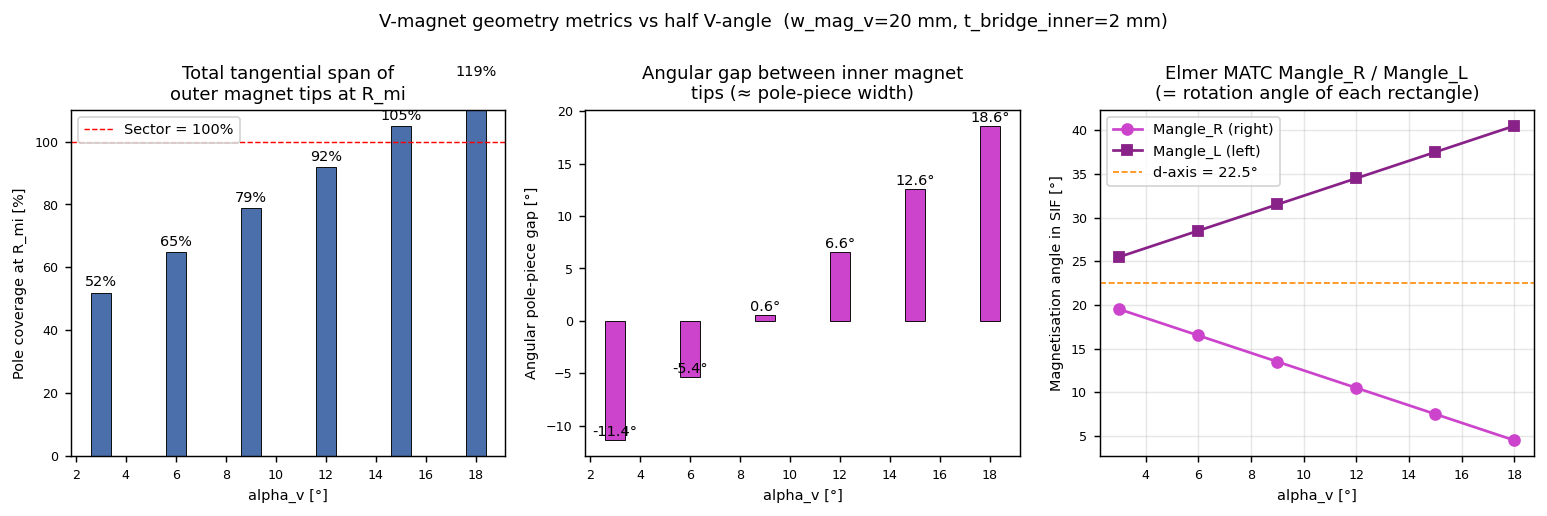

In [10]:
# ── Summary bar chart: pole coverage and apex gap vs alpha_v ─────────────────
alpha_arr   = [r['alpha_v [°]'] for r in rows]
coverage    = [r['pole cov [%]'] for r in rows]
apex_gap    = [r['apex gap [°]'] for r in rows]
mangle_R    = [r['Mangle_R [°]'] for r in rows]
mangle_L    = [r['Mangle_L [°]'] for r in rows]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Pole coverage
axes[0].bar(alpha_arr, coverage, color=C_IRON, edgecolor='k', lw=0.5)
axes[0].axhline(100, color='r', lw=0.8, ls='--', label='Sector = 100%')
axes[0].set_xlabel('alpha_v [°]')
axes[0].set_ylabel('Pole coverage at R_mi [%]')
axes[0].set_title('Total tangential span of\nouter magnet tips at R_mi')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 110)
for a, c in zip(alpha_arr, coverage):
    axes[0].text(a, c + 1, f'{c:.0f}%', ha='center', va='bottom', fontsize=8)

# Apex gap (pole piece angular width)
axes[1].bar(alpha_arr, apex_gap, color=C_MAG_R, edgecolor='k', lw=0.5)
axes[1].set_xlabel('alpha_v [°]')
axes[1].set_ylabel('Angular pole-piece gap [°]')
axes[1].set_title('Angular gap between inner magnet\ntips (≈ pole-piece width)')
for a, g in zip(alpha_arr, apex_gap):
    axes[1].text(a, g + 0.1, f'{g:.1f}°', ha='center', va='bottom', fontsize=8)

# Magnetisation angles in SIF
axes[2].plot(alpha_arr, mangle_R, 'o-', color=C_MAG_R, label='Mangle_R (right)')
axes[2].plot(alpha_arr, mangle_L, 's-', color=C_MAG_L, label='Mangle_L (left)')
axes[2].axhline(np.degrees(p_v.θs / 2), color=C_DAXIS, lw=0.9, ls='--',
                label=f'd-axis = {np.degrees(p_v.θs/2):.1f}°')
axes[2].set_xlabel('alpha_v [°]')
axes[2].set_ylabel('Magnetisation angle in SIF [°]')
axes[2].set_title('Elmer MATC Mangle_R / Mangle_L\n(= rotation angle of each rectangle)')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle('V-magnet geometry metrics vs half V-angle  (w_mag_v=20 mm, t_bridge_inner=2 mm)',
             fontsize=10)
plt.tight_layout()
plt.savefig('results/png/v_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()